In [30]:
# ---------------- SOLO PARA GOOGLE COLAB ------------------
# # Conectar Google Drive
# from google.colab import drive
# drive.mount('/content/drive')


# ruta_zip = '/content/drive/MyDrive/TrabajoFinal_PIA/dataset_4_letras.zip'
# ruta_destino = '/content/dataset_local'
# -----------------------------------------------------------

# Descomprimir el dataset en el entorno local de Colab (súper rápido)
import zipfile
import os

ruta_zip = 'dataset_4_letras.zip'
ruta_destino = 'dataset_local'

print("Descomprimiendo dataset...")
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(ruta_destino)
print("¡Descompresión completada!")

# Verificamos que las carpetas estén ahí
DIRECTORIO_DATOS = os.path.join(ruta_destino, 'dataset_4_letras')
palabras = os.listdir(DIRECTORIO_DATOS)
print(f"Total de palabras encontradas: {len(palabras)}")
print(f"Primeras 5 palabras: {palabras[:5]}")

Descomprimiendo dataset...
¡Descompresión completada!
Total de palabras encontradas: 50
Primeras 5 palabras: ['ALTA', 'AMOR', 'BAJO', 'BALA', 'BESO']


### Generador de datos

Crear una funcion que coge las imagenes por lotes y las traduce en 4 salidas independientes para evitar colapsar la memoria.

In [ ]:
import cv2
import numpy as np
import random
from tensorflow.keras.utils import to_categorical

# Parámetros globales de tu proyecto
BATCH_SIZE = 32          # Cuántas imágenes procesamos a la vez
IMG_ALTO = 128           # El alto de tus imágenes
IMG_ANCHO = 497          # El ancho final (128x4 menos el overlap)
LETRAS_ALFABETO = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def generador_datos_basico(rutas_imagenes, batch_size, alto, ancho):
    """
    Función que actúa como una cinta transportadora.
    Carga imágenes en lotes pequeños, las normaliza y divide
    la palabra del nombre de la carpeta en 4 etiquetas separadas.
    """
    # El generador debe ejecutarse en bucle infinito para Keras
    while True:
        # Barajamos las rutas para que la red no aprenda el orden
        random.shuffle(rutas_imagenes)

        # Vamos saltando de 32 en 32
        for i in range(0, len(rutas_imagenes), batch_size):
            lote_rutas = rutas_imagenes[i : i + batch_size]

            X_batch = []
            y1_batch, y2_batch, y3_batch, y4_batch = [], [], [], []

            for ruta in lote_rutas:
                # Lectura y normalización (Matemáticas básicas: de 0-255 a 0-1)
                img = cv2.imread(ruta)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img / 255.0
                X_batch.append(img)

                # Extraer la palabra de la ruta (ej: .../PAPA/PAPA_001.jpg -> "PAPA")
                ruta_estandar = ruta.replace('\\', '/')
                palabra = ruta_estandar.split('/')[-2]

                # Convertir las letras a números (A=0, B=1...) y luego a formato One-Hot
                idx_1 = LETRAS_ALFABETO.index(palabra[0])
                idx_2 = LETRAS_ALFABETO.index(palabra[1])
                idx_3 = LETRAS_ALFABETO.index(palabra[2])
                idx_4 = LETRAS_ALFABETO.index(palabra[3])

                y1_batch.append(to_categorical(idx_1, num_classes=len(LETRAS_ALFABETO)))
                y2_batch.append(to_categorical(idx_2, num_classes=len(LETRAS_ALFABETO)))
                y3_batch.append(to_categorical(idx_3, num_classes=len(LETRAS_ALFABETO)))
                y4_batch.append(to_categorical(idx_4, num_classes=len(LETRAS_ALFABETO)))

            # 'yield' entrega el lote y se pausa hasta que se le pidan más datos
            yield (np.array(X_batch), {
                'letra_1': np.array(y1_batch),
                'letra_2': np.array(y2_batch),
                'letra_3': np.array(y3_batch),
                'letra_4': np.array(y4_batch)
            })
print("Función generadora cargada en memoria.")

Función generadora cargada en memoria.


### Preparación y division del dataset

In [32]:
from sklearn.model_selection import train_test_split

todas_las_rutas = []

# Recorremos las carpetas para guardar la ruta exacta de cada imagen
for palabra in os.listdir(DIRECTORIO_DATOS):
    ruta_palabra = os.path.join(DIRECTORIO_DATOS, palabra)
    if os.path.isdir(ruta_palabra):
        for img_name in os.listdir(ruta_palabra):
            todas_las_rutas.append(os.path.join(ruta_palabra, img_name))

print(f"Total de imágenes listas para procesar: {len(todas_las_rutas)}")

Total de imágenes listas para procesar: 20000


In [33]:
# Separamos el 80% para entrenar y guardamos un 20% temporal (para test y validación)
rutas_train, rutas_temp = train_test_split(todas_las_rutas, test_size=0.2, random_state=42)

# Partimos ese 20% temporal por la mitad (10% Validación, 10% Test)
rutas_val, rutas_test = train_test_split(rutas_temp, test_size=0.5, random_state=42)

print("\n--- DISTRIBUCIÓN DEL DATASET ---")
print(f"Imágenes para Entrenamiento (Train): {len(rutas_train)}")
print(f"Imágenes para Validación (Val): {len(rutas_val)}")
print(f"Imágenes para Examen Final (Test): {len(rutas_test)}\n")


--- DISTRIBUCIÓN DEL DATASET ---
Imágenes para Entrenamiento (Train): 16000
Imágenes para Validación (Val): 2000
Imágenes para Examen Final (Test): 2000



### Creacion de los generadores

In [34]:
# Activamos la "cinta transportadora" para cada conjunto
generador_entrenamiento = generador_datos_basico(rutas_train, BATCH_SIZE, IMG_ALTO, IMG_ANCHO)
generador_validacion = generador_datos_basico(rutas_val, BATCH_SIZE, IMG_ALTO, IMG_ANCHO)
generador_test = generador_datos_basico(rutas_test, BATCH_SIZE, IMG_ALTO, IMG_ANCHO)

# Calculamos cuántas veces tiene que dar datos el generador para completar una "época"
pasos_por_epoca = len(rutas_train) // BATCH_SIZE
pasos_validacion = len(rutas_val) // BATCH_SIZE
pasos_test = len(rutas_test) // BATCH_SIZE

### Arquitectura del modelo y entrenamiento

In [35]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import os

#Entrada
entrada = Input(shape=(IMG_ALTO, IMG_ANCHO, 3), name="imagen_entrada")

#Cargar VGG16 sin su capa final y con pesos preentrenados
modelo_base = VGG16(weights='imagenet', include_top=False, input_tensor=entrada)

# Congelamos estas capas para que no olviden lo que ya saben sobre detectar bordes y formas
for capa in modelo_base.layers:
    capa.trainable = False

#Aplanado y regularizacion
x = GlobalAveragePooling2D()(modelo_base.output)
x = Dropout(0.5)(x) # Apagamos el 50% de las neuronas aleatoriamente para evitar que memorice (Overfitting)
x = Dense(256, activation='relu')(x) # Capa de razonamiento intermedio

#Las salidas
num_clases = len(LETRAS_ALFABETO)
salida_1 = Dense(num_clases, activation='softmax', name='letra_1')(x)
salida_2 = Dense(num_clases, activation='softmax', name='letra_2')(x)
salida_3 = Dense(num_clases, activation='softmax', name='letra_3')(x)
salida_4 = Dense(num_clases, activation='softmax', name='letra_4')(x)

In [36]:
from tensorflow.keras.optimizers import Adam

modelo_base.trainable = True

# Pero volvemos a congelar todo excepto el "block5" (el último bloque convolucional)
for capa in modelo_base.layers:
    if capa.name.startswith('block5'):
        capa.trainable = True
    else:
        capa.trainable = False

# Construcción y compilación
modelo = Model(inputs=entrada, outputs=[salida_1, salida_2, salida_3, salida_4])


# Usamos categorical_crossentropy porque nuestras etiquetas están en One-Hot
modelo.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss={
        'letra_1': 'categorical_crossentropy',
        'letra_2': 'categorical_crossentropy',
        'letra_3': 'categorical_crossentropy',
        'letra_4': 'categorical_crossentropy'
    },
    metrics={
        'letra_1': ['accuracy'],
        'letra_2': ['accuracy'],
        'letra_3': ['accuracy'],
        'letra_4': ['accuracy']
    }
)

# Esto vigila el 'val_loss'. Si el modelo deja de mejorar durante 3 épocas seguidas,
# detiene el entrenamiento automáticamente y recupera la mejor versión.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

### Entrenamiento

In [ ]:
EPOCAS = 15
historial = modelo.fit(
    generador_entrenamiento,
    steps_per_epoch=pasos_por_epoca,
    epochs=EPOCAS,
    validation_data=generador_validacion,
    validation_steps=pasos_validacion,
    callbacks=[early_stop]
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 201s 343ms/step - letra_1_accuracy: 0.0809 - letra_1_loss: 3.2934 - letra_2_accuracy: 0.2476 - letra_2_loss: 2.4612 - letra_3_accuracy: 0.1684 - letra_3_loss: 2.8505 - letra_4_accuracy: 0.4429 - letra_4_loss: 1.7329 - loss: 10.3380 - val_letra_1_accuracy: 0.1835 - val_letra_1_loss: 2.8266 - val_letra_2_accuracy: 0.3760 - val_letra_2_loss: 1.8757 - val_letra_3_accuracy: 0.3710 - val_letra_3_loss: 2.2683 - val_letra_4_accuracy: 0.6396 - val_letra_4_loss: 1.1799 - val_loss: 8.1505
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 173s 346ms/step - letra_1_accuracy: 0.2169 - letra_1_loss: 2.6782 - letra_2_accuracy: 0.4222 - letra_2_loss: 1.7998 - letra_3_accuracy: 0.3734 - letra_3_loss: 2.1137 - letra_4_accuracy: 0.6343 - letra_4_loss: 1.1114 - loss: 7.7031 - val_letra_1_accuracy: 0.4934 - val_letra_1_loss: 2.0647 - val_letra_2_accuracy: 0.5615 - val_letra_2_loss: 1.3487 - val_letra_3_accuracy: 0.6220 - val_letra_3_loss: 1.5516 - val_letra_4_accuracy: 0.7167 -

In [ ]:
# --- EVALUACIÓN FINAL ---
print("Evaluando el modelo con el conjunto de Test (Imágenes nunca antes vistas)...")

# Ejecutamos la evaluación usando el generador de test que creamos
resultados = modelo.evaluate(generador_test, steps=pasos_test)

print("\n" + "="*50)
print("RESULTADOS FINALES DEL MODELO (ACCURACY)")
print("="*50)

# Emparejamos los nombres de las métricas con sus valores reales y los imprimimos bonitos
for nombre_metrica, valor in zip(modelo.metrics_names, resultados):
    # Mostramos el Loss general
    if nombre_metrica == 'loss':
        print(f"Pérdida Global (Total Loss): {valor:.4f}")
        print("-" * 50)

    # Filtramos para mostrar solo las precisiones (accuracy) de las 4 letras
    elif 'accuracy' in nombre_metrica:
        # Limpiamos un poco el texto para que quede más profesional
        nombre_limpio = nombre_metrica.replace('_accuracy', '').replace('letra_', 'Letra ')
        # Multiplicamos por 100 para verlo en porcentaje
        print(f"✔️ Precisión {nombre_limpio}: {valor * 100:.2f}%")



Evaluando el modelo con el conjunto de Test (Imágenes nunca antes vistas)...
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 281ms/step - letra_1_accuracy: 0.9929 - letra_1_loss: 0.0486 - letra_2_accuracy: 0.9955 - letra_2_loss: 0.0404 - letra_3_accuracy: 0.9934 - letra_3_loss: 0.0413 - letra_4_accuracy: 1.0000 - letra_4_loss: 0.0116 - loss: 0.1419

RESULTADOS FINALES DEL MODELO (ACCURACY)
Pérdida Global (Total Loss): 0.1419
--------------------------------------------------


### Gráficas de evaluación de entrenamiento y pérdida

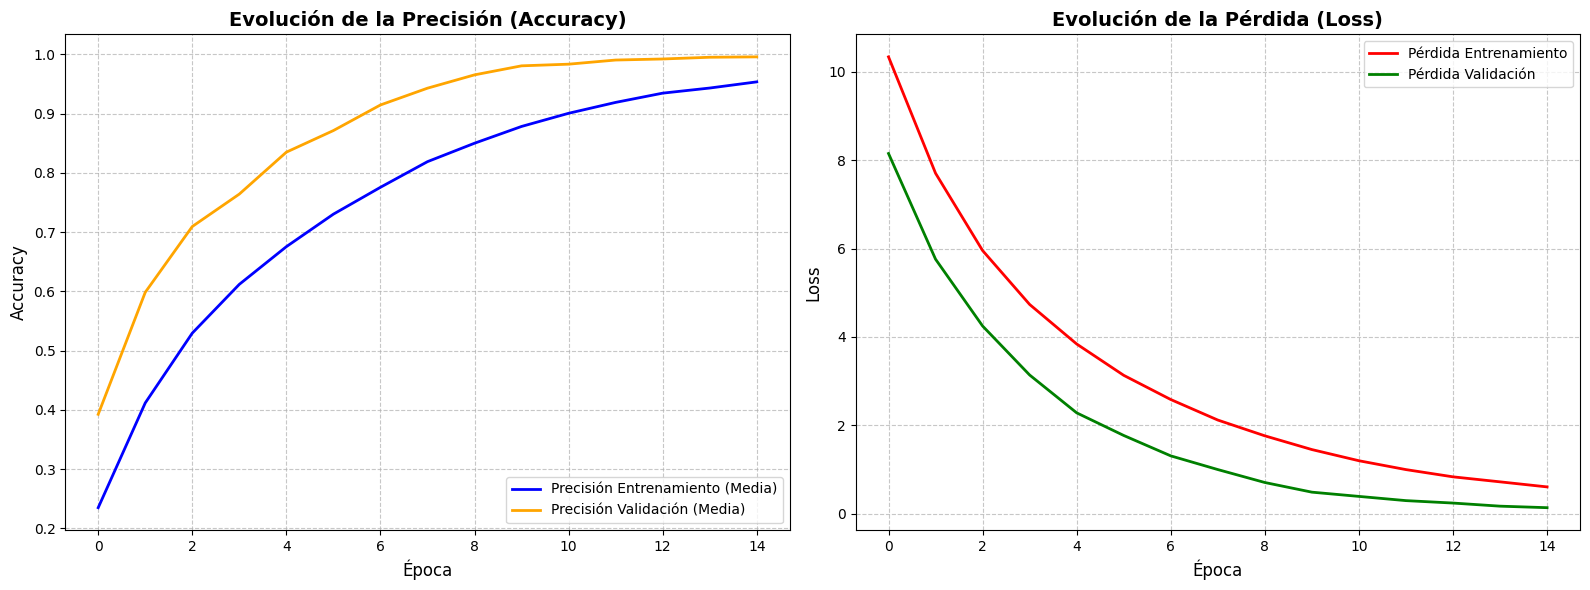

In [ ]:
import matplotlib.pyplot as plt
def generar_graficas(historial, ruta_directorio_drive):
    # Asegurarnos de que el directorio existe
    os.makedirs(ruta_directorio_drive, exist_ok=True)

    # DIBUJAR LAS GRÁFICAS
    acc_keys = [k for k in historial.history.keys() if 'accuracy' in k and 'val' not in k]

    plt.figure(figsize=(16, 6))

    # Gráfica de Precisión (Accuracy)
    plt.subplot(1, 2, 1)
    train_acc_mean = np.mean([historial.history[k] for k in acc_keys], axis=0)
    val_acc_mean = np.mean([historial.history[f'val_{k}'] for k in acc_keys], axis=0)

    plt.plot(train_acc_mean, label='Precisión Entrenamiento (Media)', color='blue', linewidth=2)
    plt.plot(val_acc_mean, label='Precisión Validación (Media)', color='orange', linewidth=2)
    plt.title('Evolución de la Precisión (Accuracy)', fontsize=14, fontweight='bold')
    plt.xlabel('Época', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Gráfica de Pérdida (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(historial.history['loss'], label='Pérdida Entrenamiento', color='red', linewidth=2)
    plt.plot(historial.history['val_loss'], label='Pérdida Validación', color='green', linewidth=2)
    plt.title('Evolución de la Pérdida (Loss)', fontsize=14, fontweight='bold')
    plt.xlabel('Época', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()

    # GUARDAR LA IMAGEN
    ruta_imagen = os.path.join(ruta_directorio_drive, 'graficas_entrenamiento.png')
    # dpi=300 garantiza que la imagen no se pixele al imprimir tu memoria
    plt.savefig(ruta_imagen, dpi=300, bbox_inches='tight')
    # Finalmente, la mostramos por pantalla
    plt.show()


generar_graficas(historial, '/content/drive/MyDrive/TrabajoFinal_PIA/')


### Guardar modelo

In [ ]:
# ruta_guardado = '/content/drive/MyDrive/TrabajoFinal_PIA/modelo_vgg16_lse.h5'
# modelo.save(ruta_guardado)

### Cargar modelo para realizar evaluación y pruebas



In [37]:
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
# ruta_modelo = '/content/drive/MyDrive/TrabajoFinal_PIA/modelo_vgg16_v2.h5'
ruta_modelo = 'modelo_vgg16_v2.h5'

modelo_cargado = load_model(ruta_modelo)




### Métricas avanzadas y matriz de confusión

En nuestro caso no se pueden medir metricas avanzadas ni matriz de confusión

### Predicción de palabra para comprobar correcto funcionamiento


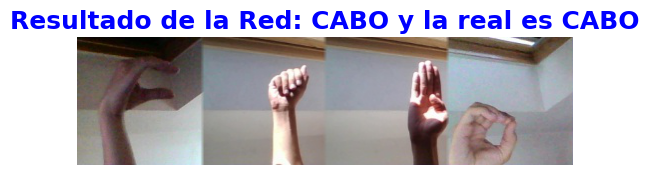

In [86]:
def predecir_palabra_completa(ruta_imagen):
    # Leer y preprocesar
    img = cv2.imread(ruta_imagen)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_norm = img_rgb / 255.0
    img_batch = np.expand_dims(img_norm, axis=0)

    # Predecir (obtenemos las 4 salidas)
    predicciones = modelo_cargado.predict(img_batch, verbose=0)

    # Decodificar y juntar las letras
    palabra = ""
    alfabeto = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

    for salida in predicciones:
        indice = np.argmax(salida[0])
        palabra += alfabeto[indice]

    return img_rgb, palabra

# 4. Probar con una imagen aleatoria del conjunto de Test
ruta_test_azar = random.choice(rutas_test)
ruta_estandar = ruta_test_azar.replace('\\', '/')
palabra_real = ruta_estandar.split('/')[-2]
imagen, resultado = predecir_palabra_completa(ruta_test_azar)

# 5. Mostrar resultado
plt.imshow(imagen)
plt.title(f"Resultado de la Red: {resultado} y la real es {palabra_real}", fontsize=18, color='blue', fontweight='bold')
plt.axis('off')
plt.show()

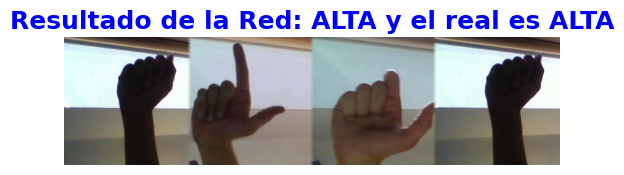

In [92]:
ruta = 'dataset_4_letras_prueba\ALTA\ALTA_000.jpg'
ruta_estandar = ruta.replace('\\', '/')
palabra_real = ruta_estandar.split('/')[-2]
imagen, resultado = predecir_palabra_completa(ruta)
plt.imshow(imagen)
plt.title(f"Resultado de la Red: {resultado} y el real es {palabra_real}", fontsize=18, color='blue', fontweight='bold')
plt.axis('off')
plt.show()